<a href="https://colab.research.google.com/github/BaoKhanh02/KHDL/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tổng hợp Phân tích Dữ liệu phim IMDb

Quy trình này bao gồm:
1. Phân tích thể loại phổ biến.
2. Điểm đánh giá theo thể loại.
3. Xu hướng phim theo năm.
4. Tương quan giữa lượt đánh giá và điểm số.
5. Phim có lượt tương tác cao nhất.
6. Dự đoán điểm số (Hồi quy).
7. Phân loại thành công (Phân lớp).

### 1. Khởi tạo và Tiền xử lý Dữ liệu Cơ bản
Đoạn mã này thực hiện tải bộ dữ liệu phim IMDb, xử lý các giá trị còn thiếu trong cột phân loại độ tuổi (`movie_rated`) bằng cách gán nhãn 'Unknown'.

In [5]:
import pandas as pd
import numpy as np

# Đọc bộ dữ liệu phim IMDb
df = pd.read_csv('merged_dataset.csv')

# Xử lý giá trị khuyết thiếu cho cột phân loại độ tuổi
df['movie_rated'] = df['movie_rated'].fillna('Unknown')

### 2. Chuyển đổi Thời lượng Phim
Thực hiện chuẩn hóa cột `run_length` từ định dạng chuỗi (ví dụ: '2h 30min') sang số phút nguyên để phục vụ tính toán định lượng và xử lý các giá trị lỗi bằng trung vị.

In [6]:
def convert_run_length_to_minutes(time_str):
    if pd.isna(time_str):
        return np.nan
    time_str = str(time_str).lower().strip()
    hours = 0
    minutes = 0
    try:
        if 'h' in time_str:
            parts = time_str.split('h')
            hours = int(parts[0].strip())
            if 'min' in parts[1]:
                minutes = int(parts[1].replace('min', '').strip())
        elif 'min' in time_str:
            minutes = int(time_str.replace('min', '').strip())
        return hours * 60 + minutes
    except:
        return np.nan

# Tạo đặc trưng mới biểu thị số phút nguyên
df['duration_min'] = df['run_length'].apply(convert_run_length_to_minutes)
# Điền các giá trị thời lượng lỗi hoặc khuyết bằng giá trị trung vị
df['duration_min'] = df['duration_min'].fillna(df['duration_min'].median())

### 3. Xác định Biến Mục tiêu 'Success'
Định nghĩa một bộ phim 'thành công' dựa trên hai tiêu chí: có điểm đánh giá IMDb từ 7.5 trở lên và có số lượng người đánh giá (độ phổ biến) cao hơn mức trung bình của toàn bộ dữ liệu.

In [7]:
# Tính toán giá trị trung vị của tổng số lượt đánh giá
median_raters = df['num_raters'].median()

# Tạo nhãn mục tiêu thành công (1) hoặc thất bại (0)
df['success'] = np.where((df['rating'] >= 7.5) & (df['num_raters'] >= median_raters), 1, 0)

### 4. Kỹ nghệ Đặc trưng (Feature Engineering)
Thực hiện làm sạch danh sách thể loại và áp dụng kỹ thuật **One-hot Encoding** cho các biến phân loại (`genres`, `movie_rated`) để chuyển đổi chúng thành định dạng số học mà mô hình Học máy có thể hiểu được.

In [8]:
# Làm sạch dấu cách và phân tách các thể loại phim
df['genres_cleaned'] = df['genres'].str.rstrip('; ').str.split('; ')

# Thực hiện One-hot Encoding cho danh sách đa thể loại
genres_encoded = df['genres_cleaned'].str.join('|').str.get_dummies()

# Thực hiện One-hot Encoding cho cột movie_rated
movie_rated_encoded = pd.get_dummies(df['movie_rated'], prefix='rated', drop_first=True)

# Kết hợp các đặc trưng đã mã hóa vào bảng dữ liệu chính
df_features = pd.concat([df[['year', 'duration_min', 'num_raters', 'num_reviews']],
                         genres_encoded,
                         movie_rated_encoded], axis=1)

### 5. Phân tích Top 10 Thể loại Phổ biến
Thống kê và trực quan hóa 10 thể loại phim xuất hiện nhiều nhất trong tập dữ liệu để hiểu về xu hướng sản xuất phim.

Top 10 thể loại phim phổ biến nhất:
    genre  count percentage
    Drama    693     46.20%
Adventure    385     25.67%
   Action    384     25.60%
   Comedy    373     24.87%
 Thriller    250     16.67%
    Crime    208     13.87%
   Sci-Fi    203     13.53%
  Mystery    200     13.33%
Biography    183     12.20%
  Romance    176     11.73%


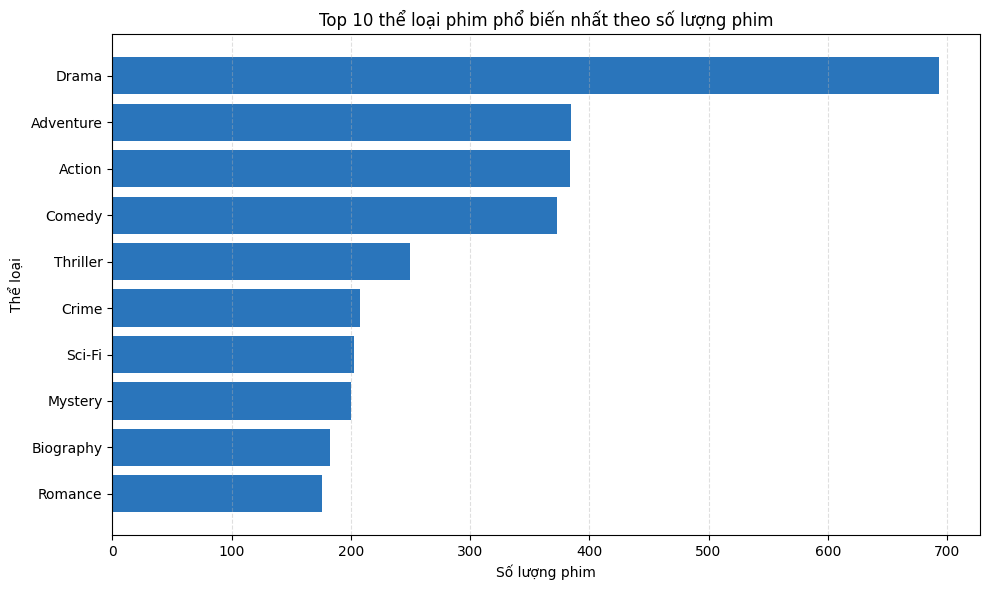

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

# Tách danh sách thể loại và đếm tần suất mỗi nhãn thể loại riêng lẻ
genre_list = (
    df['genres']
    .dropna()
    .astype(str)
    .str.rstrip('; ')
    .str.split('; ')
    .explode()
    .str.strip()
)

genre_counts = genre_list.value_counts()

top10_genres = genre_counts.head(10).reset_index()
top10_genres.columns = ['genre', 'count']

total_movies = len(df)
top10_genres['percentage'] = top10_genres['count'] / total_movies * 100

print('Top 10 thể loại phim phổ biến nhất:')
print(top10_genres.to_string(index=False, formatters={'percentage': '{:.2f}%'.format}))

# Vẽ biểu đồ cột Top 10 thể loại phổ biến nhất
plt.figure(figsize=(10, 6))
plt.barh(top10_genres['genre'][::-1], top10_genres['count'][::-1], color='#2a75bb')
plt.xlabel('Số lượng phim')
plt.ylabel('Thể loại')
plt.title('Top 10 thể loại phim phổ biến nhất theo số lượng phim')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 6. Điểm đánh giá Trung bình theo Thể loại
Phân tích xem thể loại phim nào thường nhận được sự ưu ái từ khán giả thông qua điểm rating trung bình, sau khi đã loại bỏ các thể loại có quá ít mẫu dữ liệu.

--- Điểm đánh giá trung bình theo thể loại ---
genre_list  avg_rating  movie_count
     Crime        7.77          208
 Biography        7.69          183
     Drama        7.66          693
     Sport        7.64           14
 Animation        7.54          122
   Mystery        7.53          200
   History        7.50          137
       War        7.50          116
  Thriller        7.46          250
    Sci-Fi        7.46          203
 Adventure        7.44          385
    Comedy        7.35          373
   Romance        7.34          176
   Fantasy        7.30          170
    Action        7.28          384
     Music        7.06          108
    Horror        7.06          143


/tmp/ipykernel_1305/1502154875.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


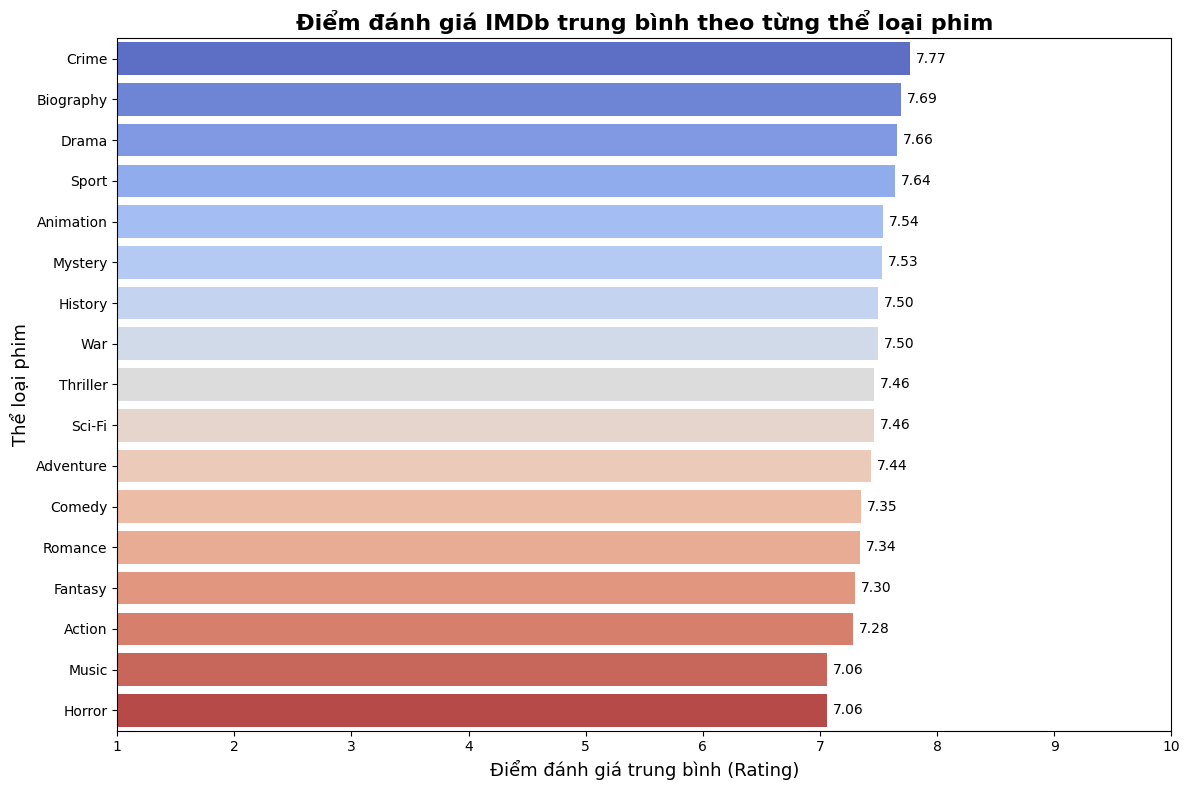

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ tệp csv
df = pd.read_csv('merged_dataset.csv')

# 2. Làm sạch chuỗi genres và phân rã (explode) thành các hàng độc lập
# Loại bỏ dấu chấm phẩy thừa ở cuối và tách chuỗi bằng '; '
df['genre_list'] = df['genres'].astype(str).str.rstrip('; ').str.split('; ')
df_exploded = df.explode('genre_list')

# 3. Tính điểm rating trung bình và số lượng phim cho từng thể loại
genre_rating_stats = df_exploded.groupby('genre_list').agg(
    avg_rating=('rating', 'mean'),
    movie_count=('rating', 'count')
).reset_index()

# Lọc bỏ các thể loại có quá ít phim (ví dụ < 5 phim) để tránh số liệu nhiễu ngoại lai
genre_rating_stats = genre_rating_stats[genre_rating_stats['movie_count'] >= 5]

# Sắp xếp theo điểm đánh giá trung bình giảm dần
genre_rating_stats = genre_rating_stats.sort_values(by='avg_rating', ascending=False).reset_index(drop=True)

# Làm tròn điểm trung bình và in kết quả
genre_rating_stats['avg_rating'] = genre_rating_stats['avg_rating'].round(2)
print('--- Điểm đánh giá trung bình theo thể loại ---')
print(genre_rating_stats[['genre_list', 'avg_rating', 'movie_count']].to_string(index=False))

# 4. Vẽ trực quan hóa biểu đồ cột điểm đánh giá trung bình theo thể loại
plt.figure(figsize=(12, 8))
sns.barplot(
    x='avg_rating',
    y='genre_list',
    data=genre_rating_stats,
    palette='coolwarm',
    dodge=False
)
plt.title('Điểm đánh giá IMDb trung bình theo từng thể loại phim', fontsize=16, fontweight='bold')
plt.xlabel('Điểm đánh giá trung bình (Rating)', fontsize=13)
plt.ylabel('Thể loại phim', fontsize=13)
plt.xlim(1, 10)

for index, value in enumerate(genre_rating_stats['avg_rating']):
    plt.text(value + 0.05, index, f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 7. Xu hướng Sản xuất Phim theo Năm
Trực quan hóa số lượng phim được sản xuất qua các thời kỳ và xác định năm có sản lượng phim cao nhất trong lịch sử IMDb.

--- Năm có nhiều phim nhất ---
Năm: 2013
Số lượng phim: 73 phim

Top 10 năm có nhiều phim nhất:
 year  movie_count
 2013           73
 2007           71
 2004           70
 2014           69
 2011           65
 2012           63
 2006           62
 2009           59
 2016           58
 2008           57


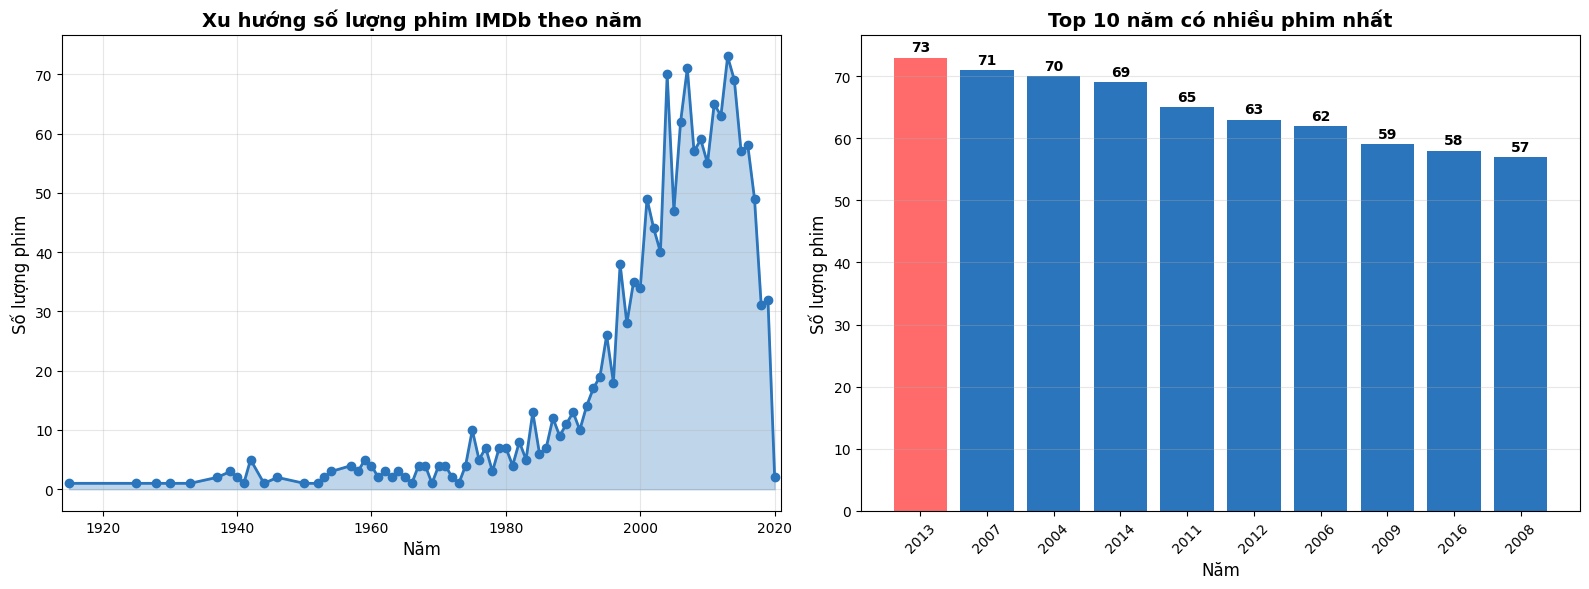

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ tệp csv
df = pd.read_csv('merged_dataset.csv')

# 2. Đếm số lượng phim theo năm
movies_by_year = df.groupby('year').size().reset_index(name='movie_count')

# 3. Tìm năm có nhiều phim nhất
max_year = movies_by_year.loc[movies_by_year['movie_count'].idxmax()]
print('--- Năm có nhiều phim nhất ---')
print(f'Năm: {int(max_year["year"])}')
print(f'Số lượng phim: {int(max_year["movie_count"])} phim')

# In Top 10 năm có nhiều phim nhất
top10_years = movies_by_year.nlargest(10, 'movie_count')
print('\nTop 10 năm có nhiều phim nhất:')
print(top10_years.to_string(index=False))

# 4. Vẽ biểu đồ xu hướng số lượng phim theo năm
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ đường: Xu hướng phim qua từng năm
ax1.plot(movies_by_year['year'], movies_by_year['movie_count'], marker='o', linewidth=2, markersize=6, color='#2a75bb')
ax1.fill_between(movies_by_year['year'], movies_by_year['movie_count'], alpha=0.3, color='#2a75bb')
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Số lượng phim', fontsize=12)
ax1.set_title('Xu hướng số lượng phim IMDb theo năm', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(movies_by_year['year'].min() - 1, movies_by_year['year'].max() + 1)

# Biểu đồ cột: Top 10 năm có nhiều phim
colors = ['#ff6b6b' if year == max_year['year'] else '#2a75bb' for year in top10_years['year']]
ax2.bar(range(len(top10_years)), top10_years['movie_count'], color=colors)
ax2.set_xticks(range(len(top10_years)))
ax2.set_xticklabels([int(year) for year in top10_years['year']], rotation=45)
ax2.set_xlabel('Năm', fontsize=12)
ax2.set_ylabel('Số lượng phim', fontsize=12)
ax2.set_title('Top 10 năm có nhiều phim nhất', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên cột
for i, v in enumerate(top10_years['movie_count']):
    ax2.text(i, v + 1, str(int(v)), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### 8. Tương quan giữa Độ phổ biến và Điểm số
Sử dụng biểu đồ phân tán và hệ số tương quan Pearson để kiểm tra giả thuyết: Liệu những bộ phim có nhiều người đánh giá hơn có xu hướng đạt điểm cao hơn hay không.

Số bản ghi sử dụng: 1500
Hệ số Pearson r=0.475, p=3.901e-85
Hệ số Spearman rho=0.538, p=1.634e-113


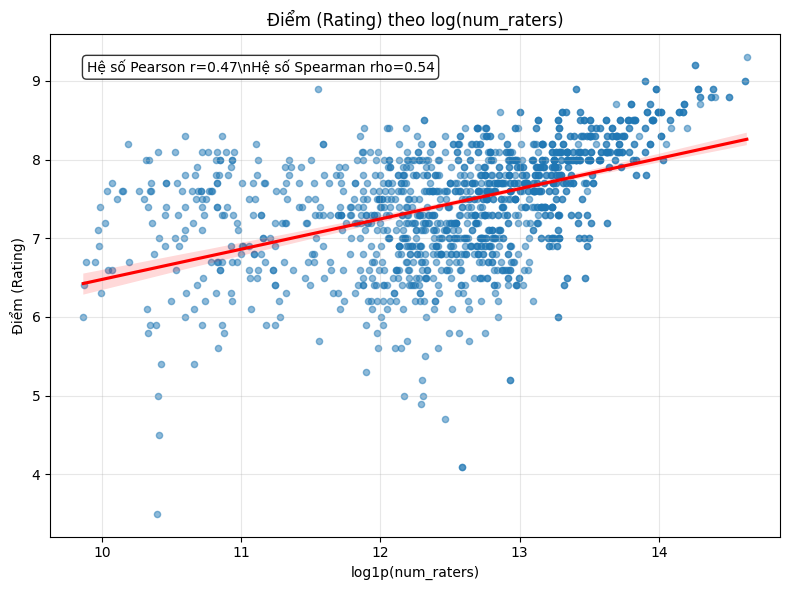

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Phân tích mối liên hệ giữa rating và num_raters (dùng num_raters làm proxy cho phổ biến/doanh thu)
df = pd.read_csv('merged_dataset.csv')
if 'num_raters' not in df.columns:
    print('Cột num_raters không tồn tại trong dữ liệu. Hãy chỉ định cột doanh thu nếu có.')
else:
    sub = df[['rating','num_raters']].dropna().copy()
    sub['num_raters'] = pd.to_numeric(sub['num_raters'], errors='coerce')
    sub = sub.dropna()
    sub['log_num_raters'] = np.log1p(sub['num_raters'].astype(float))

    if sub.empty:
        print('Không có dữ liệu để phân tích sau khi làm sạch.')
    else:
        pearson_r, pearson_p = pearsonr(sub['rating'], sub['log_num_raters'])
        spearman_r, spearman_p = spearmanr(sub['rating'], sub['log_num_raters'])

        print('Số bản ghi sử dụng:', len(sub))
        print(f'Hệ số Pearson r={pearson_r:.3f}, p={pearson_p:.3e}')
        print(f'Hệ số Spearman rho={spearman_r:.3f}, p={spearman_p:.3e}')

        plt.figure(figsize=(8,6))
        sns.regplot(x='log_num_raters', y='rating', data=sub, scatter_kws={'s':20,'alpha':0.5}, line_kws={'color':'red'})
        plt.xlabel('log1p(num_raters)')
        plt.ylabel('Điểm (Rating)')
        plt.title('Điểm (Rating) theo log(num_raters)')
        plt.grid(alpha=0.3)
        plt.annotate(f'Hệ số Pearson r={pearson_r:.2f}\\nHệ số Spearman rho={spearman_r:.2f}', xy=(0.05,0.95), xycoords='axes fraction', va='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
        plt.tight_layout()
        plt.show()

### 9. Tìm kiếm Phim có Lượt tương tác Cao nhất
Xác định 'ông vua' của các bảng xếp hạng dựa trên tổng số lượt người tham gia đánh giá trên hệ thống.

Phim có số lượt đánh giá cao nhất:
- The Shawshank Redemption (Năm: 1994, Rating: 9.30, num_raters: 2258845)


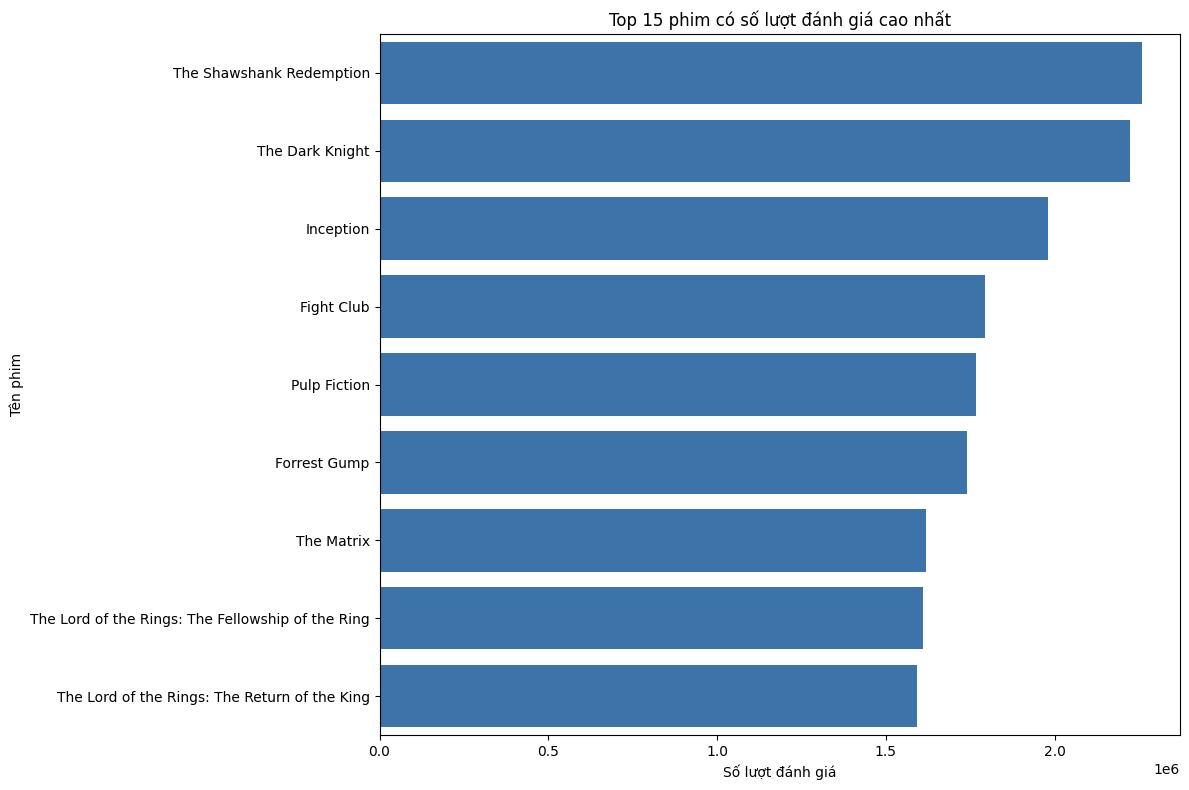

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tìm phim có số lượng người đánh giá cao nhất
# Dùng cột num_raters làm chỉ số lượt đánh giá

df = pd.read_csv('merged_dataset.csv')
if 'num_raters' not in df.columns:
    print('Cột num_raters không tồn tại. Không thể xác định phim có số lượt đánh giá cao nhất.')
else:
    df['num_raters'] = pd.to_numeric(df['num_raters'], errors='coerce')
    df_raters = df.dropna(subset=['num_raters']).copy()
    if df_raters.empty:
        print('Không có dữ liệu num_raters hợp lệ để phân tích.')
    else:
        max_raters = int(df_raters['num_raters'].max())
        top_movies = df_raters[df_raters['num_raters'] == max_raters]
        print('Phim có số lượt đánh giá cao nhất:')
        for idx, row in top_movies.iterrows():
            print(f"- {row['name']} (Năm: {int(row['year']) if pd.notna(row['year']) else 'N/A'}, Rating: {row['rating']:.2f}, num_raters: {int(row['num_raters'])})")

        # Vẽ biểu đồ Top 15 phim theo num_raters
        top15 = df_raters.sort_values(by='num_raters', ascending=False).head(15)
        plt.figure(figsize=(12, 8))
        sns.barplot(x='num_raters', y='name', data=top15, color='#2a75bb')
        plt.title('Top 15 phim có số lượt đánh giá cao nhất')
        plt.xlabel('Số lượt đánh giá')
        plt.ylabel('Tên phim')
        plt.tight_layout()
        plt.show()

### 10. Xây dựng và Đánh giá Mô hình Học máy
Thực hiện huấn luyện song song hai bài toán: **Hồi quy** (dự đoán điểm số cụ thể) và **Phân lớp** (dự đoán khả năng thành công), sau đó so sánh hiệu năng giữa các thuật toán như Linear Regression, Decision Tree và Random Forest.

In [14]:
# Tính toán lại cột 'success' vì biến df đã bị ghi đè ở các bước trước
median_raters = df['num_raters'].median()
df['success'] = np.where((df['rating'] >= 7.5) & (df['num_raters'] >= median_raters), 1, 0)

# Thiết lập tập dữ liệu đầu vào cho Bài toán Hồi quy
X_reg = df_features.copy()
y_reg = df['rating']

# Thiết lập tập dữ liệu đầu vào cho Bài toán Phân lớp (Loại bỏ các trường liên quan đến rating/raters)
X_class = df_features.drop(columns=['num_raters', 'num_reviews'])
y_class = df['success']

In [15]:
import pandas as pd
import numpy as np
import re

def load_and_clean_base_data(file_path):
    """
    Bước 1: Đọc dữ liệu và xử lý làm sạch cơ bản (trùng lặp, giá trị thiếu)
    """
    # Đọc tệp dữ liệu csv
    df = pd.read_csv(file_path)

    # Loại bỏ các bản ghi trùng lặp hoàn toàn
    df = df.drop_duplicates()

    # Làm đầy giá trị khuyết thiếu cho cột phân loại độ tuổi bằng nhãn 'Unknown'
    df['movie_rated'] = df['movie_rated'].fillna('Unknown')

    return df

def convert_run_length_to_minutes(time_str):
    """
    Bước 2: Hàm bổ trợ sử dụng Regex để chuyển đổi chuỗi 'run_length' (2h 28min) sang số phút
    """
    if pd.isna(time_str):
        return np.nan

    time_str = str(time_str).lower().strip()
    hours = 0
    minutes = 0

    try:
        # Tìm kiếm định dạng có chứa giờ 'h'
        hour_match = re.search(r'(\d+)\s*h', time_str)
        if hour_match:
            hours = int(hour_match.group(1))

        # Tìm kiếm định dạng có chứa phút 'min'
        minute_match = re.search(r'(\d+)\s*min', time_str)
        if minute_match:
            minutes = int(minute_match.group(1))

        # Trường hợp chuỗi chỉ chứa số thuần túy (ví dụ: '95')
        if not hour_match and not minute_match and time_str.isdigit():
            minutes = int(time_str)

        return hours * 60 + minutes
    except:
        return np.nan

def execute_feature_engineering(df):
    """
    Bước 3: Thực hiện Kỹ nghệ đặc trưng (Thời lượng, Biến mục tiêu Success, Mã hóa Thể loại)
    """
    # 1. Áp dụng hàm chuyển đổi thời lượng phim sang số phút
    df['duration_min'] = df['run_length'].apply(convert_run_length_to_minutes)
    # Điền các giá trị thời lượng lỗi hoặc trống bằng giá trị trung vị (Median)
    df['duration_min'] = df['duration_min'].fillna(df['duration_min'].median())

    # 2. Tính toán ngưỡng trung vị cho số lượt đánh giá để xác định độ phổ biến
    median_raters = df['num_raters'].median()

    # 3. Tạo biến mục tiêu nhị phân 'success' (Thành công: rating >= 7.5 VÀ num_raters >= median)
    df['success'] = np.where((df['rating'] >= 7.5) & (df['num_raters'] >= median_raters), 1, 0)

    # 4. Xử lý bóc tách và mã hóa One-hot cho cột đa thể loại 'genres'
    # Loại bỏ dấu chấm phẩy thừa ở cuối chuỗi và tách thành danh sách
    df['genres_cleaned'] = df['genres'].str.rstrip('; ').str.split('; ')
    # Sử dụng get_dummies để chuyển danh sách thể loại thành các cột nhị phân (0 hoặc 1)
    genres_encoded = df['genres_cleaned'].str.join('|').str.get_dummies()

    # 5. Mã hóa One-hot cho cột phân loại độ tuổi 'movie_rated'
    movie_rated_encoded = pd.get_dummies(df['movie_rated'], prefix='rated', drop_first=True, dtype=int)

    # 6. Hợp nhất các phần dữ liệu đã xử lý thành bảng đặc trưng tổng hợp
    df_features = pd.concat([
        df[['year', 'duration_min', 'num_raters', 'num_reviews']],
        genres_encoded,
        movie_rated_encoded
    ], axis=1)

    return df, df_features

# ==========================================
# THỰC THI CHƯƠNG TRÌNH TIỀN XỬ LÝ
# ==========================================
if __name__ == "__main__":
    # Đường dẫn tới tệp dữ liệu thực tế
    data_path = 'merged_dataset.csv'

    print("--- Bắt đầu quy trình tiền xử lý dữ liệu phim IMDb ---")

    # Thực hiện làm sạch cơ bản
    df_cleaned = load_and_clean_base_data(data_path)
    print(f"1. Đã làm sạch dữ liệu. Tổng số bản ghi duy nhất: {df_cleaned.shape[0]}")

    # Thực hiện kỹ nghệ đặc trưng và mã hóa số học
    df_final, df_ml_ready = execute_feature_engineering(df_cleaned)
    print("2. Đã chuyển đổi thời lượng 'run_length' sang số phút 'duration_min'.")
    print(f"3. Đã tạo biến mục tiêu 'success'. Số lượng phim thành công (1): {df_final['success'].sum()}")
    print(f"4. Đã hoàn thành mã hóa One-hot cho 'genres' và 'movie_rated'.")
    print(f"--> Kích thước ma trận đặc trưng đầu vào phục vụ Học máy: {df_ml_ready.shape}")

--- Bắt đầu quy trình tiền xử lý dữ liệu phim IMDb ---
1. Đã làm sạch dữ liệu. Tổng số bản ghi duy nhất: 1280
2. Đã chuyển đổi thời lượng 'run_length' sang số phút 'duration_min'.
3. Đã tạo biến mục tiêu 'success'. Số lượng phim thành công (1): 445
4. Đã hoàn thành mã hóa One-hot cho 'genres' và 'movie_rated'.
--> Kích thước ma trận đặc trưng đầu vào phục vụ Học máy: (1280, 35)


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import các mô hình cho Bài toán Hồi quy
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Import các mô hình cho Bài toán Phân lớp
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import các chỉ số đánh giá hiệu năng
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Giả định df_final và df_ml_ready đã được tạo ra từ chương trình tiền xử lý ở mục 3.5
# Thống nhất dữ liệu đầu vào cho chương trình dự đoán
def build_and_evaluate_models(df_final, df_ml_ready):
    """
    Hàm thực thi huấn luyện và đánh giá song song hai bài toán Học máy
    """
    # =========================================================================
    # BÀI TOÁN 1: HỒI QUY DỰ ĐOÁN ĐIỂM SỐ (RATING)
    # =========================================================================
    print("\n=======================================================")
    print("THỰC THI BÀI TOÁN 1: HỒI QUY DỰ ĐOÁN ĐIỂM SỐ (RATING)")
    print("=======================================================")

    # Thiết lập ma trận đặc trưng X_reg và vector mục tiêu y_reg
    X_reg = df_ml_ready.copy()
    y_reg = df_final['rating']

    # Chia tập dữ liệu Train/Test theo tỷ lệ 80/20 cho bài toán hồi quy
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )

    # Khởi tạo danh sách các mô hình hồi quy đề xuất
    reg_models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=42),
        "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    }

    # Huấn luyện và đánh giá từng mô hình hồi quy
    reg_results = {}
    for name, model in reg_models.items():
        # Huấn luyện mô hình
        model.fit(X_train_reg, y_train_reg)
        # Dự đoán trên tập kiểm thử
        y_pred = model.predict(X_test_reg)

        # Tính toán các chỉ số lỗi và hiệu năng
        mae = mean_absolute_error(y_test_reg, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
        r2 = r2_score(y_test_reg, y_pred)

        reg_results[name] = [mae, rmse, r2]
        print(f"Mô hình [{name}] -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R² Score: {r2:.3f}")

    # =========================================================================
    # BÀI TOÁN 2: PHÂN LỚP DỰ BÁO SỰ THÀNH CÔNG (SUCCESS)
    # =========================================================================
    print("\n=======================================================")
    print("THỰC THI BÀI TOÁN 2: PHÂN LỚP DỰ BÁO THÀNH CÔNG (SUCCESS)")
    print("=======================================================")

    # Thiết lập ma trận đặc trưng X_class (Loại bỏ các trường liên quan đến chất lượng/độ phổ biến để tránh Data Leakage)
    X_class = df_ml_ready.drop(columns=['num_raters', 'num_reviews'])
    y_class = df_final['success']

    # Chia tập dữ liệu Train/Test theo tỷ lệ 80/20 cho bài toán phân lớp
    X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
        X_class, y_class, test_size=0.2, random_state=42
    )

    # Khởi tạo danh sách các mô hình phân lớp đề xuất
    class_models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree Classifier": DecisionTreeClassifier(max_depth=8, random_state=42),
        "Random Forest Classifier": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
    }

    # Huấn luyện và đánh giá từng mô hình phân lớp
    class_results = {}
    for name, model in class_models.items():
        # Huấn luyện mô hình
        model.fit(X_train_class, y_train_class)
        # Dự đoán nhãn lớp trên tập kiểm thử
        y_pred_class = model.predict(X_test_class)

        # Tính toán các chỉ số độ chính xác
        accuracy = accuracy_score(y_test_class, y_pred_class)
        precision = precision_score(y_test_class, y_pred_class, zero_division=0)
        recall = recall_score(y_test_class, y_pred_class, zero_division=0)
        f1 = f1_score(y_test_class, y_pred_class, zero_division=0)

        class_results[name] = [accuracy, precision, recall, f1]
        print(f"Mô hình [{name}] -> Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1-score: {f1:.3f}")

    return reg_results, class_results

In [17]:
import pandas as pd
import numpy as np

def predict_new_movie(new_movie_data, trained_reg_model, trained_class_model, feature_columns):
    """
    Chương trình tiếp nhận thông tin một bộ phim mới và trả về kết quả dự báo kép
    """
    print("\n--- ĐANG TIẾN HÀNH PHÂN TÍCH VÀ DỰ BÁO PHIM MỚI ---")

    # 1. Chuyển đổi dữ liệu đầu vào của người dùng thành cấu trúc DataFrame
    df_new = pd.DataFrame([new_movie_data])

    # 2. Tiền xử lý: Chuyển đổi định dạng thời lượng thô sang số phút
    # (Sử dụng hàm convert_run_length_to_minutes đã định nghĩa ở mục 3.5)
    df_new['duration_min'] = df_new['run_length'].apply(convert_run_length_to_minutes)

    # 3. Khởi tạo một hàng dữ liệu trống chứa đầy đủ tất cả các cột đặc trưng (Feature Columns) của mô hình
    encoded_input = pd.DataFrame(0, index=[0], columns=feature_columns)

    # 4. Điền các giá trị định lượng cơ bản
    encoded_input['year'] = df_new['year'].values[0]
    encoded_input['duration_min'] = df_new['duration_min'].values[0]

    # Điền giá trị giả định về lượt tương tác cho bài toán hồi quy (lấy theo mức trung bình hệ thống)
    if 'num_raters' in feature_columns:
        encoded_input['num_raters'] = 50000  # Giả định phim đạt mức phổ biến trung bình
    if 'num_reviews' in feature_columns:
        encoded_input['num_reviews'] = 250

    # 5. Khớp dữ liệu One-hot Encoding cho Thể loại (Genres)
    user_genres = df_new['genres'].str.rstrip('; ').str.split('; ').values[0]
    for genre in user_genres:
        genre_col = genre.strip()
        if genre_col in encoded_input.columns:
            encoded_input[genre_col] = 1

    # 6. Khớp dữ liệu One-hot Encoding cho Giới hạn độ tuổi (Movie Rated)
    user_rate = "rated_" + str(df_new['movie_rated'].values[0])
    if user_rate in encoded_input.columns:
        encoded_input[user_rate] = 1

    # =========================================================================
    # THỰC THI DỰ BÁO TỪ CÁC MÔ HÌNH
    # =========================================================================
    # Nhánh 1: Dự đoán điểm số liên tục (Hồi quy)
    # Lọc đúng các cột thuộc tính phục vụ bài toán hồi quy
    X_input_reg = encoded_input[trained_reg_model.feature_names_in_]
    predicted_rating = trained_reg_model.predict(X_input_reg)[0]

    # Nhánh 2: Dự báo xác suất và nhãn thành công (Phân lớp)
    # Loại bỏ các cột tương tác để tránh Data Leakage theo đúng thiết kế
    X_input_class = encoded_input[trained_class_model.feature_names_in_]
    predicted_success_label = trained_class_model.predict(X_input_class)[0]
    predicted_success_proba = trained_class_model.predict_proba(X_input_class)[0][1]

    # =========================================================================
    # IN KẾT QUẢ TRỰC QUAN KHÁCH QUAN
    # =========================================================================
    print(f"Tên phim thử nghiệm: '{df_new['name'].values[0]}'")
    print(f"-> Thể loại lựa chọn: {user_genres}")
    print(f"-> Dự đoán Điểm số IMDb (Rating): {predicted_rating:.2f} / 10 điểm")
    print(f"-> Khả năng bứt phá thành công: {predicted_success_proba * 100:.1f}%")

    if predicted_success_label == 1:
        print("=> ĐÁNH GIÁ: Bộ phim có tiềm năng lớn để trở thành tác phẩm THÀNH CÔNG (Thu hút người xem và đạt điểm tốt).")
    else:
        print("=> ĐÁNH GIÁ: Bộ phim có rủi ro cao hoặc kén người xem (Xác suất đạt thành công đại chúng thấp).")

# ==========================================
# THỬ NGHIỆM TRÊN MỘT BỘ PHIM MỚI GIẢ ĐỊNH
# ==========================================
# Giả sử ta muốn kiểm tra một dự án phim Viễn tưởng - Hành động sắp sản xuất vào năm 2027
new_movie = {
    'name': 'Future Awakening 2027',
    'year': 2027,
    'movie_rated': 'PG-13',
    'run_length': '2h 15min',
    'genres': 'Action; Sci-Fi; Adventure; '
}

# Gọi hàm thực thi dự báo (với các mô hình tối ưu Random Forest đã huấn luyện ở mục 3.6)
# predict_new_movie(new_movie, best_rf_regressor, best_rf_classifier, df_ml_ready.columns)

In [18]:
import warnings
from pathlib import Path
import pandas as pd

warnings.filterwarnings('ignore')

# Load data, run feature engineering and evaluate models
data_path = 'merged_dataset.csv'
if not Path(data_path).exists():
    raise FileNotFoundError(f"{data_path} not found")

df_raw = pd.read_csv(data_path)
df_cleaned = load_and_clean_base_data(data_path)
df_final, df_ml_ready = execute_feature_engineering(df_cleaned)

print('Chạy huấn luyện và đánh giá các mô hình...')
reg_results, class_results = build_and_evaluate_models(df_final, df_ml_ready)

# Tạo DataFrame từ kết quả và lưu
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

reg_df = pd.DataFrame.from_dict(reg_results, orient='index', columns=['MAE','RMSE','R2'])
class_df = pd.DataFrame.from_dict(class_results, orient='index', columns=['Accuracy','Precision','Recall','F1'])

print('\n--- Kết quả Hồi quy (dự đoán Rating) ---')
display(reg_df)
reg_df.to_csv(out_dir / 'regression_results.csv')

print('\n--- Kết quả Phân lớp (success) ---')
display(class_df)
class_df.to_csv(out_dir / 'classification_results.csv')

print(f"Đã lưu kết quả vào thư mục: {out_dir}")

Chạy huấn luyện và đánh giá các mô hình...

THỰC THI BÀI TOÁN 1: HỒI QUY DỰ ĐOÁN ĐIỂM SỐ (RATING)
Mô hình [Linear Regression] -> MAE: 0.387 | RMSE: 0.522 | R² Score: 0.409
Mô hình [Decision Tree Regressor] -> MAE: 0.428 | RMSE: 0.639 | R² Score: 0.115
Mô hình [Random Forest Regressor] -> MAE: 0.335 | RMSE: 0.469 | R² Score: 0.524

THỰC THI BÀI TOÁN 2: PHÂN LỚP DỰ BÁO THÀNH CÔNG (SUCCESS)
Mô hình [Logistic Regression] -> Accuracy: 0.730 | Precision: 0.706 | Recall: 0.400 | F1-score: 0.511
Mô hình [Decision Tree Classifier] -> Accuracy: 0.699 | Precision: 0.633 | Recall: 0.344 | F1-score: 0.446
Mô hình [Random Forest Classifier] -> Accuracy: 0.727 | Precision: 0.794 | Recall: 0.300 | F1-score: 0.435

--- Kết quả Hồi quy (dự đoán Rating) ---


,MAE,RMSE,R2
Linear Regression,0.387316,0.521559,0.409489
Decision Tree Regressor,0.427631,0.638546,0.114873
Random Forest Regressor,0.334512,0.468506,0.523512



--- Kết quả Phân lớp (success) ---


,Accuracy,Precision,Recall,F1
Logistic Regression,0.730469,0.705882,0.400000,0.510638
Decision Tree Classifier,0.699219,0.632653,0.344444,0.446043
Random Forest Classifier,0.726562,0.794118,0.300000,0.435484


Đã lưu kết quả vào thư mục: outputs


### 11. Trực quan hóa kết quả đánh giá mô hình

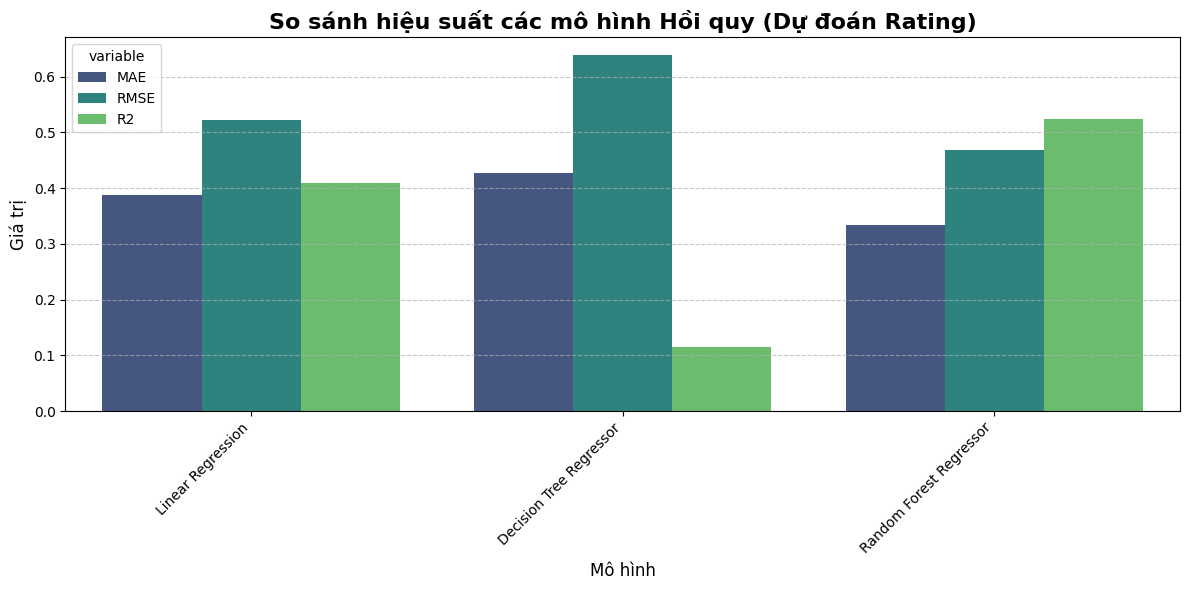

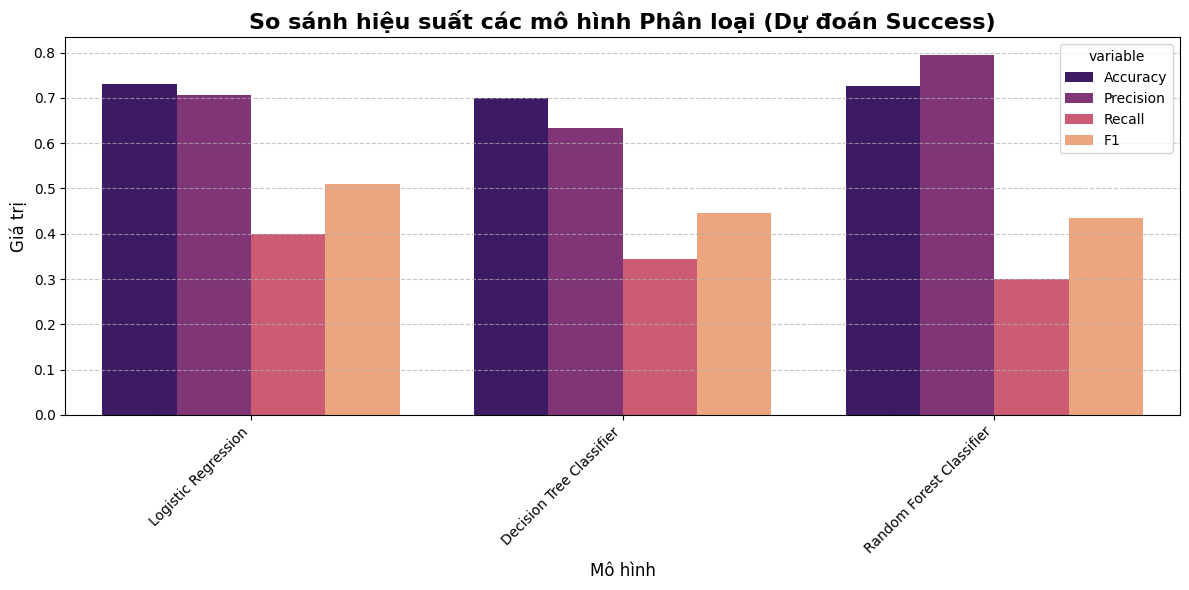

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Ensure outputs directory exists and results are available or loaded
out_dir = Path('outputs')
reg_results_path = out_dir / 'regression_results.csv'
class_results_path = out_dir / 'classification_results.csv'

# Check if reg_df is defined, if not, attempt to load from file
if 'reg_df' not in locals():
    try:
        reg_df = pd.read_csv(reg_results_path, index_col=0)
        print(f"Đã tải 'reg_df' từ '{reg_results_path}'")
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy tệp '{reg_results_path}'. Vui lòng chạy lại các ô trước đó để tạo kết quả.")
        reg_df = None # Set to None to prevent further errors
    except Exception as e:
        print(f"Lỗi khi tải reg_df: {e}")
        reg_df = None

# Check if class_df is defined, if not, attempt to load from file
if 'class_df' not in locals():
    try:
        class_df = pd.read_csv(class_results_path, index_col=0)
        print(f"Đã tải 'class_df' từ '{class_results_path}'")
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy tệp '{class_results_path}'. Vui lòng chạy lại các ô trước đó để tạo kết quả.")
        class_df = None
    except Exception as e:
        print(f"Lỗi khi tải class_df: {e}")
        class_df = None

# Visualize Regression Results
plt.figure(figsize=(12, 6))
if reg_df is not None:
    sns.barplot(data=reg_df.reset_index().melt(id_vars='index'), x='index', y='value', hue='variable', palette='viridis')
    plt.title('So sánh hiệu suất các mô hình Hồi quy (Dự đoán Rating)', fontsize=16, fontweight='bold')
    plt.xlabel('Mô hình', fontsize=12)
    plt.ylabel('Giá trị', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Không thể hiển thị biểu đồ hồi quy vì dữ liệu 'reg_df' không có sẵn.")

# Visualize Classification Results
plt.figure(figsize=(12, 6))
if class_df is not None:
    sns.barplot(data=class_df.reset_index().melt(id_vars='index'), x='index', y='value', hue='variable', palette='magma')
    plt.title('So sánh hiệu suất các mô hình Phân loại (Dự đoán Success)', fontsize=16, fontweight='bold')
    plt.xlabel('Mô hình', fontsize=12)
    plt.ylabel('Giá trị', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Không thể hiển thị biểu đồ phân loại vì dữ liệu 'class_df' không có sẵn.")